In [10]:
import numpy as np
import matplotlib.pyplot as plt
import random
import os


In [17]:

cube_files = os.listdir("cubes")
print("Total cubes:", len(cube_files))

# Pick 3 random cubes
samples = random.sample(cube_files, 3)
print("Selected cubes:", samples)

Total cubes: 484
Selected cubes: ['cube_458.npz', 'cube_231.npz', 'cube_170.npz']


In [18]:
lulc_colors = {
    1: (0, 0, 255),        # Water
    2: (0, 128, 0),        # Trees
    3: (124, 252, 0),      # Grass
    4: (0, 255, 255),      # Flooded vegetation
    5: (255, 255, 0),      # Crops
    6: (34, 139, 34),      # Shrubland
    7: (255, 0, 0),        # Built area
    8: (210, 180, 140),    # Bare ground
    9: (255, 250, 250),    # Snow/Ice
    10: (160, 82, 45),     # Rangeland (brownish)
    11: (138, 43, 226),    # Moss/Lichen (purple)
}

In [19]:
def visualize_cube(path):
    
    cube = np.load(os.path.join("cubes", path))
    
    img = cube["image"]      # (4,128,128)
    mask = cube["mask"]      # (128,128)
    
    # Convert to RGB (B04, B03, B02)
    rgb = np.stack([
        img[2],  # Red
        img[1],  # Green
        img[0],  # Blue
    ], axis=-1)

    # Normalize RGB for display
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())
    
    # Create color mask
    color_mask = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)
    
    for cls, color in lulc_colors.items():
        color_mask[mask == cls] = color

    # Plot
    plt.figure(figsize=(12,4))
    
    plt.subplot(1,3,1)
    plt.title("Sentinel RGB")
    plt.imshow(rgb)
    plt.axis("off")
    
    plt.subplot(1,3,2)
    plt.title("LULC Mask")
    plt.imshow(color_mask)
    plt.axis("off")
    
    plt.subplot(1,3,3)
    plt.title("Overlay")
    plt.imshow(rgb)
    plt.imshow(color_mask, alpha=0.4)
    plt.axis("off")
    
    plt.show()
    
    print("Unique classes in mask:", np.unique(mask))

Visualizing: cube_458.npz


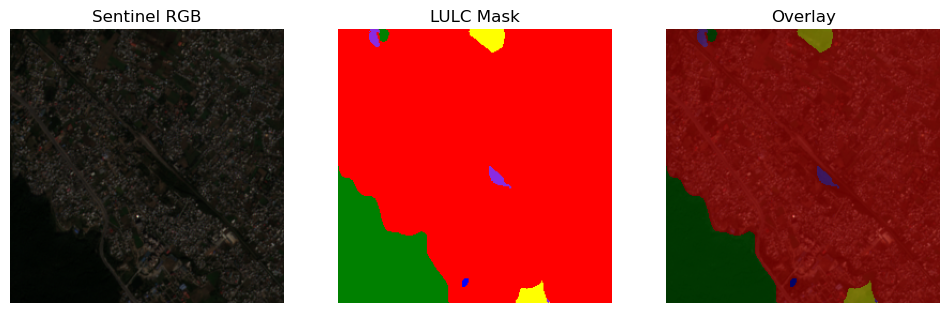

Unique classes in mask: [ 1  2  5  7 11]
Visualizing: cube_231.npz


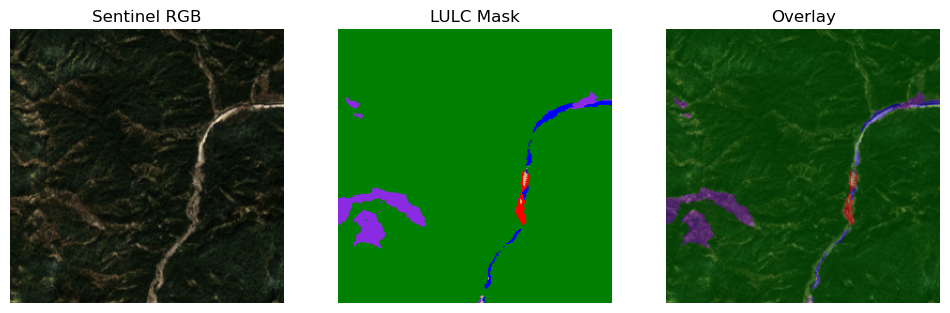

Unique classes in mask: [ 1  2  7  8 11]
Visualizing: cube_170.npz


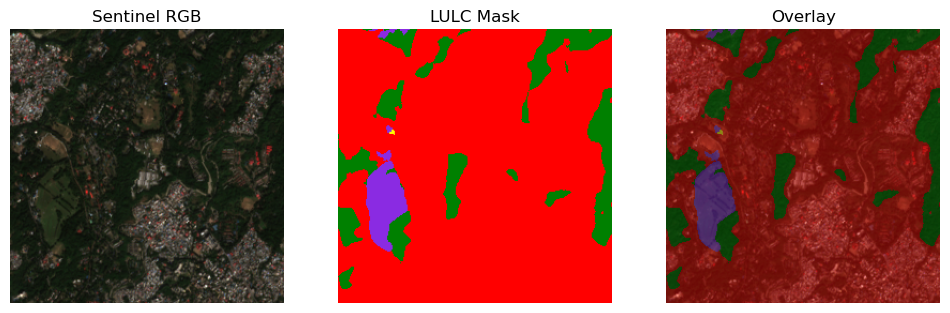

Unique classes in mask: [ 2  5  7 11]


In [20]:
for sample in samples:
    print("Visualizing:", sample)
    visualize_cube(sample)

In [15]:
cube = np.load(os.path.join("cubes", samples[0]))

print("Image shape:", cube["image"].shape)
print("Mask shape:", cube["mask"].shape)

Image shape: (4, 256, 256)
Mask shape: (256, 256)


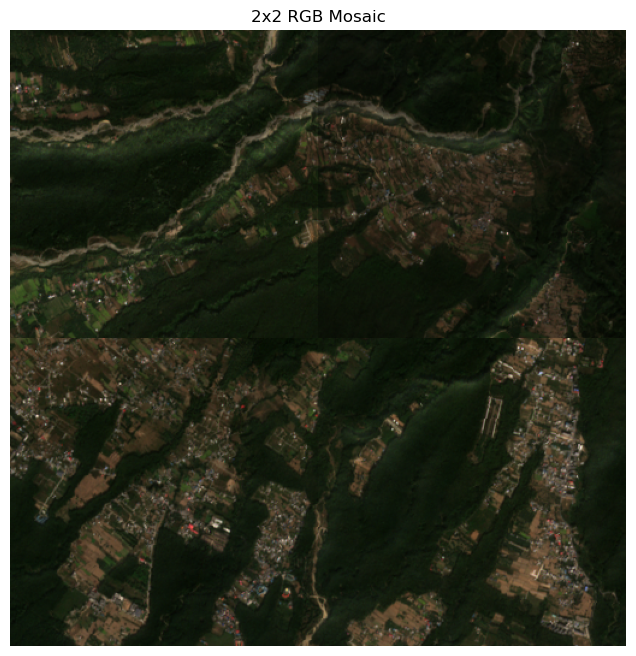

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Load 4 consecutive cubes
cube_ids = [0, 1, 23, 24]  # adjust if needed

imgs = []
masks = []

for idx in cube_ids:
    cube = np.load(f"cubes/cube_{idx}.npz")
    imgs.append(cube["image"])
    masks.append(cube["mask"])

# Extract RGB
rgbs = []
for img in imgs:
    rgb = np.stack([img[2], img[1], img[0]], axis=-1)
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-6)
    rgbs.append(rgb)

# Build 2x2 mosaic
top = np.concatenate([rgbs[0], rgbs[1]], axis=1)
bottom = np.concatenate([rgbs[2], rgbs[3]], axis=1)
mosaic_rgb = np.concatenate([top, bottom], axis=0)

# Same for masks
top_mask = np.concatenate([masks[0], masks[1]], axis=1)
bottom_mask = np.concatenate([masks[2], masks[3]], axis=1)
mosaic_mask = np.concatenate([top_mask, bottom_mask], axis=0)

plt.figure(figsize=(10,8))
plt.imshow(mosaic_rgb)
plt.title("2x2 RGB Mosaic")
plt.axis("off")
plt.show()

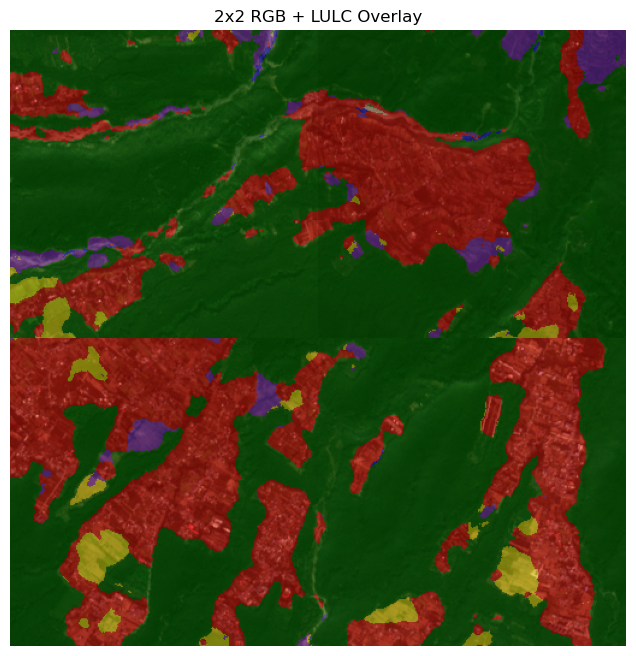

In [22]:
color_mask = np.zeros((*mosaic_mask.shape, 3), dtype=np.uint8)

for cls, color in lulc_colors.items():
    color_mask[mosaic_mask == cls] = color

plt.figure(figsize=(10,8))
plt.imshow(mosaic_rgb)
plt.imshow(color_mask, alpha=0.4)
plt.title("2x2 RGB + LULC Overlay")
plt.axis("off")
plt.show()

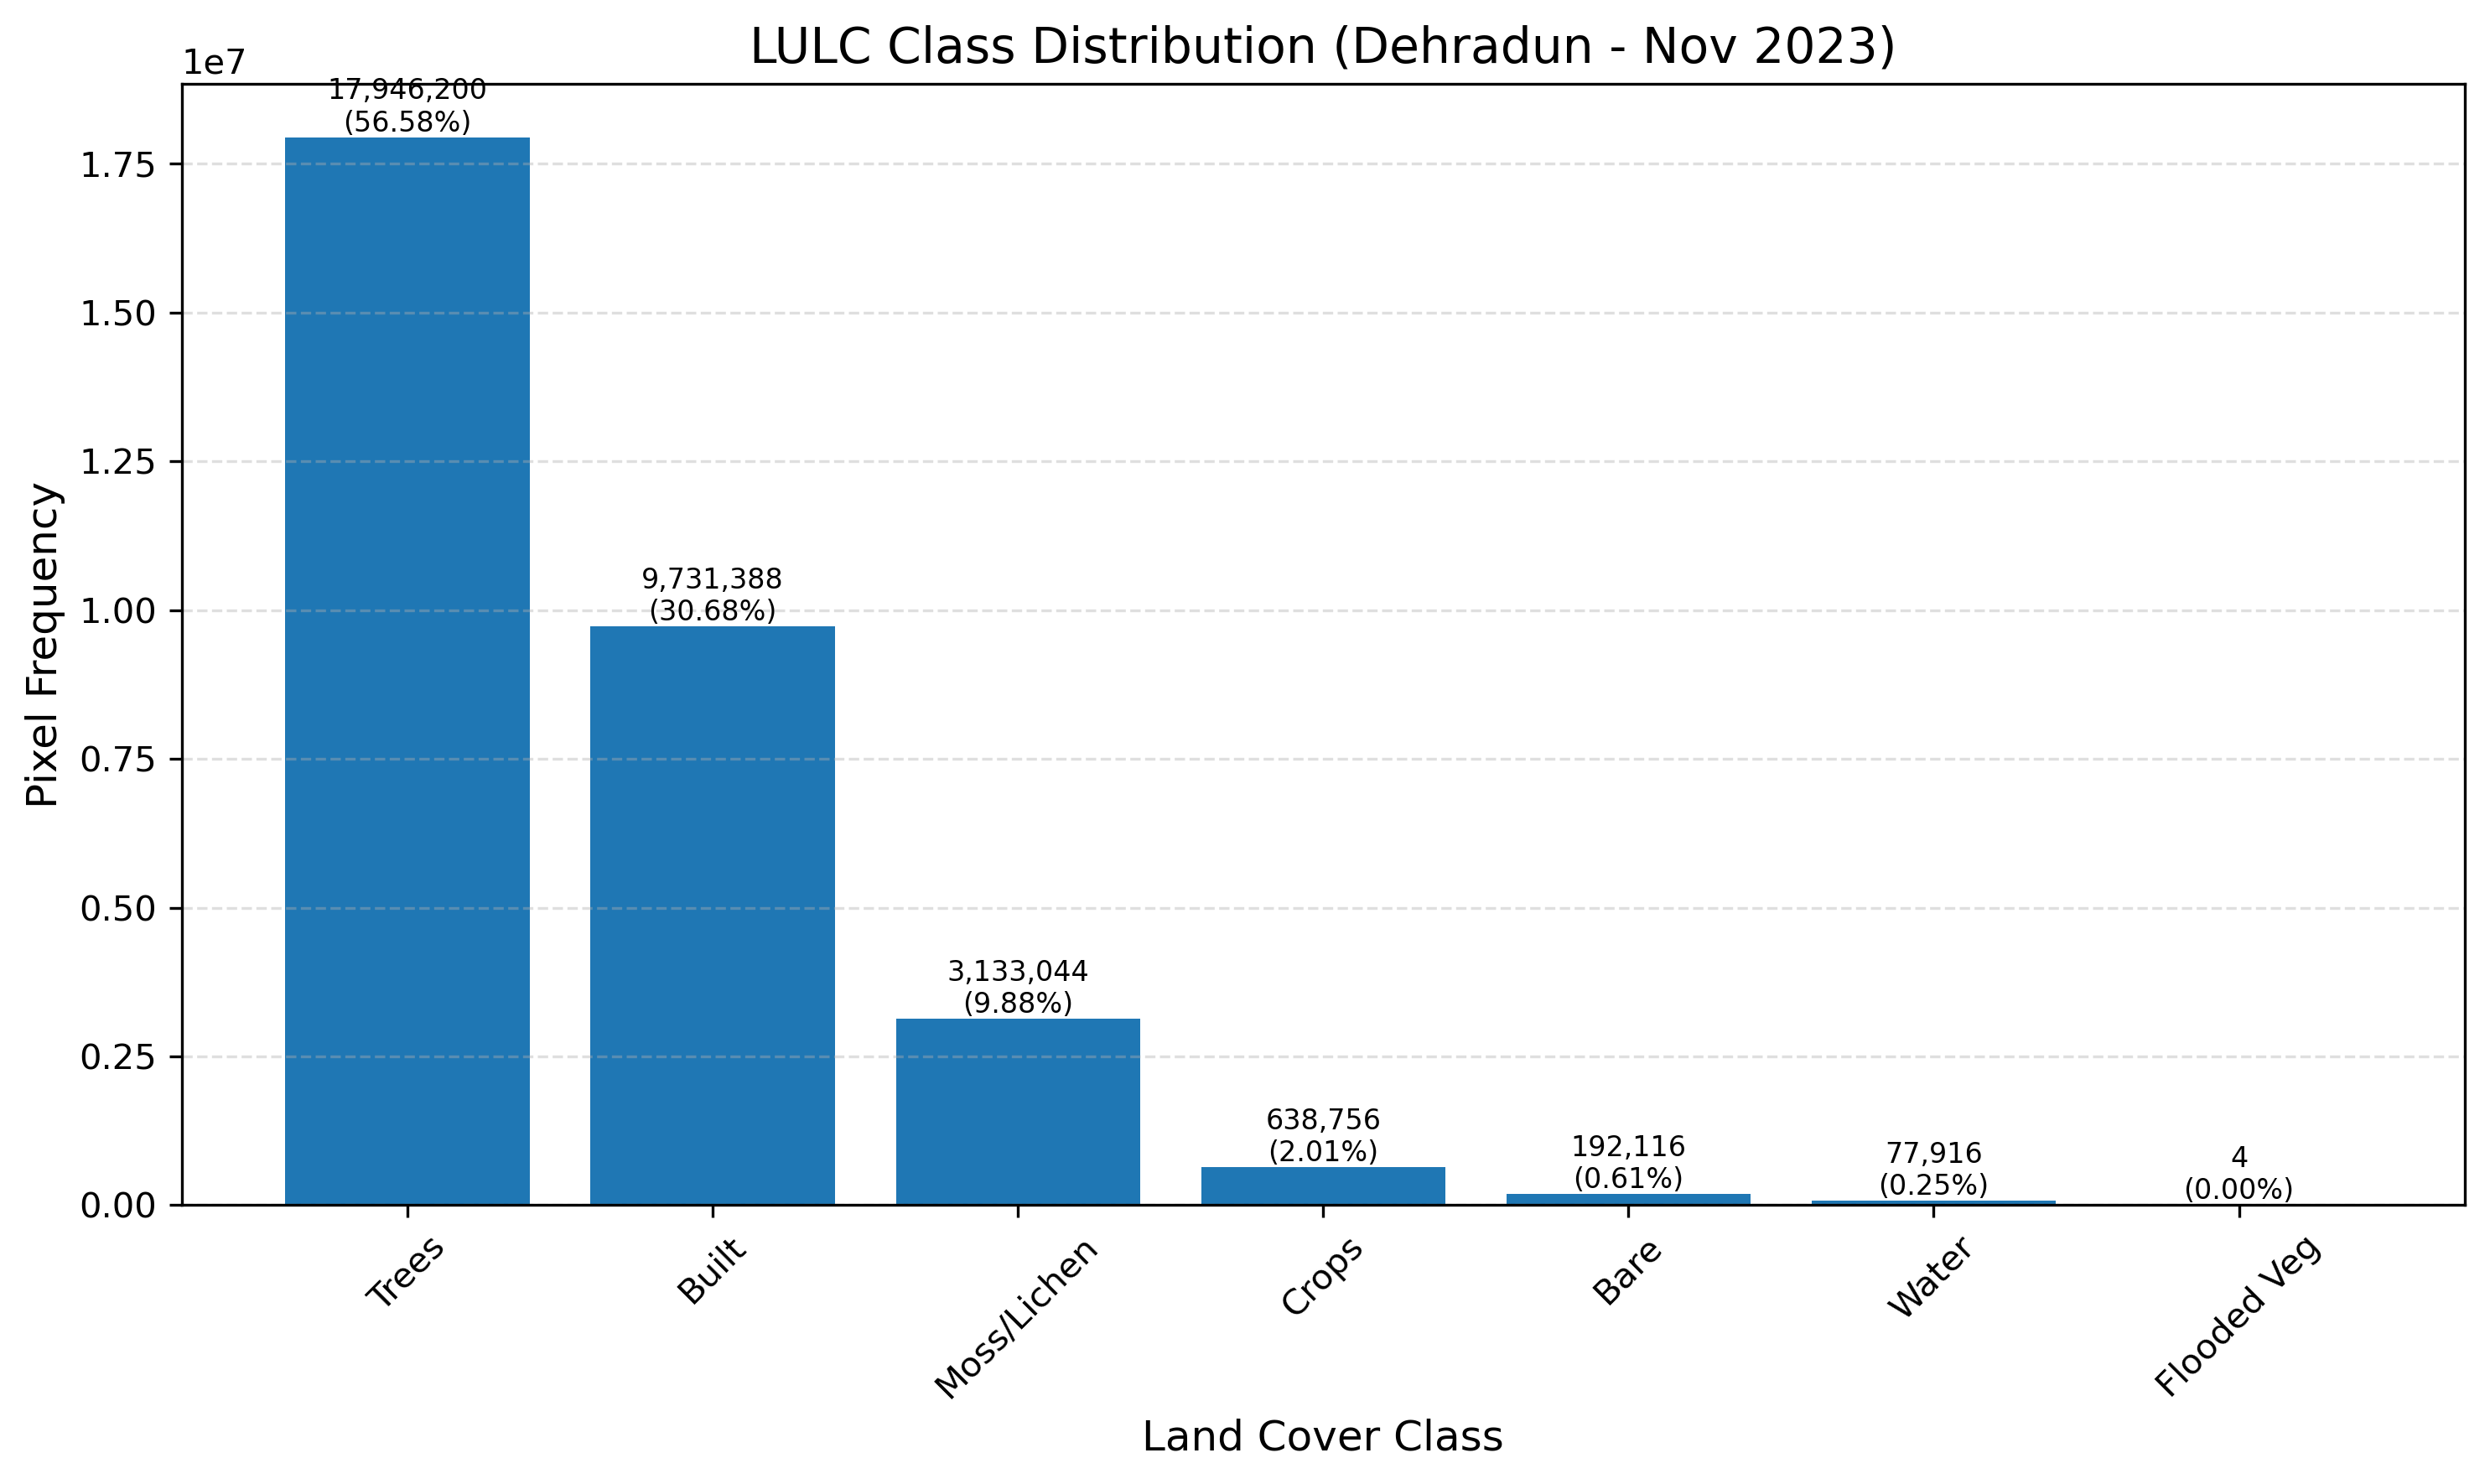

In [24]:
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# ----------------------------
# 1️⃣ Class Name Mapping (IO LULC v02)
# ----------------------------
class_names = {
    1: "Water",
    2: "Trees",
    3: "Grass",
    4: "Flooded Veg",
    5: "Crops",
    6: "Shrubland",
    7: "Built",
    8: "Bare",
    9: "Snow/Ice",
    10: "Rangeland",
    11: "Moss/Lichen",
}

# ----------------------------
# 2️⃣ Collect All Pixels
# ----------------------------
all_classes = []

for f in os.listdir("cubes"):
    mask = np.load(os.path.join("cubes", f))["mask"]
    all_classes.extend(mask.flatten())

counts = Counter(all_classes)

# Remove classes not present
counts = {k: v for k, v in counts.items() if k in class_names}

# Sort by frequency (descending)
counts = dict(sorted(counts.items(), key=lambda x: x[1], reverse=True))

classes = list(counts.keys())
frequencies = list(counts.values())
total_pixels = sum(frequencies)
percentages = [(v / total_pixels) * 100 for v in frequencies]

class_labels = [class_names[c] for c in classes]

# ----------------------------
# 3️⃣ Plot
# ----------------------------
plt.figure(figsize=(10,6), dpi=300)

bars = plt.bar(class_labels, frequencies)

# Annotate bars with count and %
for bar, freq, pct in zip(bars, frequencies, percentages):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{freq:,}\n({pct:.2f}%)",
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.title("LULC Class Distribution (Dehradun - Nov 2023)", fontsize=14)
plt.xlabel("Land Cover Class", fontsize=12)
plt.ylabel("Pixel Frequency", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# Optional: Save for publication
# plt.savefig("class_distribution_dehradun.png", dpi=600, bbox_inches="tight")

In [25]:
empty_count = 0
single_class_count = 0

for f in os.listdir("cubes"):
    mask = np.load(os.path.join("cubes", f))["mask"]
    
    unique = np.unique(mask)
    
    if len(unique) == 0:
        empty_count += 1
    if len(unique) == 1:
        single_class_count += 1

print("Empty cubes:", empty_count)
print("Single-class cubes:", single_class_count)
print("Total cubes:", len(os.listdir("cubes")))

Empty cubes: 0
Single-class cubes: 8
Total cubes: 484
